In [ ]:
!pip install scikit-learn

In [ ]:

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)


In [ ]:
from google.colab import files
# Upload files from your local machine
# The uploaded files will be stored in the 'uploaded' variable as a dictionary
uploaded = files.upload()

Saving heart_disease_data.csv to heart_disease_data.csv


In [ ]:
df = pd.read_csv("heart_disease_data.csv")

In [ ]:
print(df.shape)
df.head()

(303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [ ]:
df.shape

(303, 14)

In [ ]:
X = df.drop("target", axis=1)
y = df["target"]

In [ ]:
y.value_counts()

,count
target,
1,165
0,138


In [ ]:
y.value_counts(normalize=True)

,proportion
target,
1,0.544554
0,0.455446


In [ ]:
X.nunique()


,0
age,41
sex,2
cp,4
trestbps,49
chol,152
fbs,2
restecg,3
thalach,91
exang,2
oldpeak,40


In [ ]:
numeric_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
df.duplicated().sum()

np.int64(1)

In [ ]:
df = df.drop_duplicates().reset_index(drop=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.shape

(302, 14)

In [ ]:
X = df.drop("target", axis=1)
y = df["target"]


In [ ]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (302, 13)
y shape: (302,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (241, 13)
Testing: (61, 13)


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

numeric_features = [
    "age", "trestbps", "chol", "thalach", "oldpeak"
]

categorical_features = [
    "sex", "cp", "fbs", "restecg",
    "exang", "slope", "ca", "thal"
]

In [ ]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [ ]:
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

TRaining baseline Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'trestbps', 'chol',
                                                   'thalach', 'oldpeak']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'cp', 'fbs',
                                                   'restecg', 'exang', 'slope',
                                                   'ca', 'thal'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [ ]:
y_pred = logistic_model.predict(X_test)
y_prob = logistic_model.predict_proba(X_test)[:, 1]

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.8524590163934426
Precision: 0.8529411764705882
Recall   : 0.8787878787878788
F1 Score : 0.8656716417910447
ROC-AUC  : 0.8971861471861471


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

cv_results = cross_validate(
    logistic_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

for metric in scoring:
    scores = cv_results[f"test_{metric}"]
    print(f"{metric}: {scores.mean():.4f} ± {scores.std():.4f}")

accuracy: 0.8590 ± 0.0400
precision: 0.8626 ± 0.0483
recall: 0.8852 ± 0.0548
f1: 0.8721 ± 0.0360
roc_auc: 0.9081 ± 0.0347


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "classifier__C": [0.001, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, 100],
    "classifier__penalty": ["l1", "l2"],
    "classifier__solver": ["liblinear"]
}

grid_search = GridSearchCV(
    logistic_model,
    param_grid=param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV ROC-AUC:", grid_search.best_score_)

Best parameters: {'classifier__C': 0.1, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}
Best CV ROC-AUC: 0.9111370111370112


In [ ]:
best_model = grid_search.best_estimator_

y_pred_tuned = best_model.predict(X_test)
y_prob_tuned = best_model.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred_tuned))
print("Precision:", precision_score(y_test, y_pred_tuned))
print("Recall   :", recall_score(y_test, y_pred_tuned))
print("F1 Score :", f1_score(y_test, y_pred_tuned))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_tuned))

Accuracy : 0.8524590163934426
Precision: 0.8333333333333334
Recall   : 0.9090909090909091
F1 Score : 0.8695652173913043
ROC-AUC  : 0.8939393939393939


[[22  6]
 [ 3 30]]


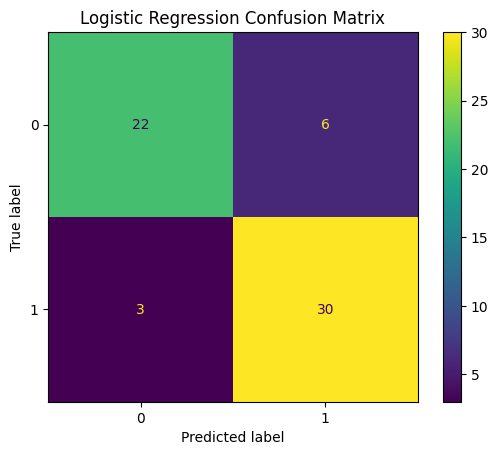

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_tuned)

print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["0", "1"]
).plot()

plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [ ]:
l1_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        penalty="l1",
        solver="liblinear",
        max_iter=1000,
        random_state=42
    ))
])

In [ ]:
l1_grid = GridSearchCV(
    l1_model,
    {
        "classifier__C": [0.001, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, 100]
    },
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

l1_grid.fit(X_train, y_train)

print("Best L1 parameters:", l1_grid.best_params_)
print("Best L1 CV ROC-AUC:", l1_grid.best_score_)

Best L1 parameters: {'classifier__C': 0.5}
Best L1 CV ROC-AUC: 0.9052577052577053


In [ ]:
l1_best = l1_grid.best_estimator_

feature_names = l1_best.named_steps[
    "preprocessor"
].get_feature_names_out()

coefficients = l1_best.named_steps[
    "classifier"
].coef_[0]

selected_features = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

selected_features = selected_features[
    selected_features["coefficient"] != 0
]

print("Selected features:", len(selected_features))
print(selected_features)

Selected features: 15
                   feature  coefficient
1        numeric__trestbps    -0.142767
2            numeric__chol    -0.402851
3         numeric__thalach     0.231076
4         numeric__oldpeak    -0.522093
5       categorical__sex_0     0.318522
6       categorical__sex_1    -0.354836
7        categorical__cp_0    -1.455962
9        categorical__cp_2     0.165983
14  categorical__restecg_1     0.230160
17    categorical__exang_1    -0.529815
19    categorical__slope_1    -0.312009
20    categorical__slope_2     0.035699
21       categorical__ca_0     1.182104
28     categorical__thal_2     1.177462
29     categorical__thal_3    -0.281305


In [ ]:
y_pred_l1 = l1_best.predict(X_test)
y_prob_l1 = l1_best.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred_l1))
print("Precision:", precision_score(y_test, y_pred_l1))
print("Recall   :", recall_score(y_test, y_pred_l1))
print("F1 Score :", f1_score(y_test, y_pred_l1))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_l1))

Accuracy : 0.8360655737704918
Precision: 0.8108108108108109
Recall   : 0.9090909090909091
F1 Score : 0.8571428571428571
ROC-AUC  : 0.8917748917748918


In [61]:
import shap

In [62]:
best_model = grid_search.best_estimator_

In [63]:
print(best_model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'trestbps', 'chol',
                                                   'thalach', 'oldpeak']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncode

In [64]:
X_train_transformed = best_model.named_steps[
    "preprocessor"
].transform(X_train)

X_test_transformed = best_model.named_steps[
    "preprocessor"
].transform(X_test)

feature_names = best_model.named_steps[
    "preprocessor"
].get_feature_names_out()

In [65]:
print("Original features:", X_train.shape[1])
print("Transformed features:", X_train_transformed.shape[1])

Original features: 13
Transformed features: 30


In [67]:
masker = shap.maskers.Independent(
    X_train_transformed,
    max_samples=241
)

explainer = shap.LinearExplainer(
    best_model.named_steps["classifier"],
    masker
)

In [68]:
shap_values = explainer(X_test_transformed)

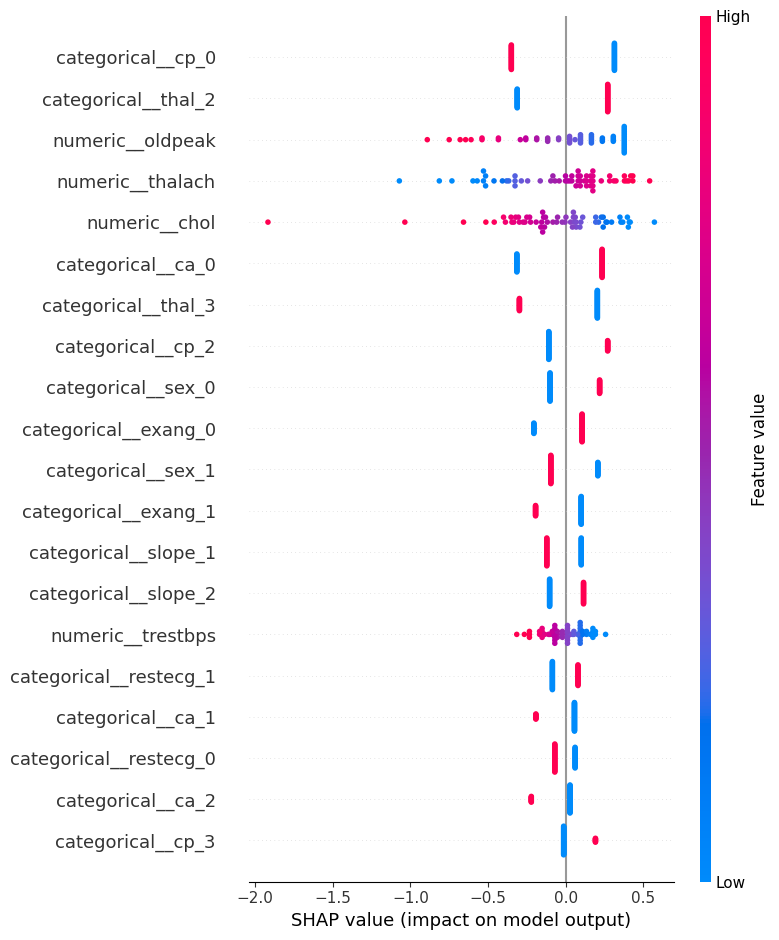

In [69]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names
)

In [70]:
patient_index = 0

patient = X_test.iloc[[patient_index]]
actual = y_test.iloc[patient_index]

print(patient)
print("Actual:", actual)

     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
178   57    1   0       150   276    0        0      112      1      0.6   

     slope  ca  thal  
178      1   1     1  
Actual: 0


In [72]:
prediction = best_model.predict(patient)[0]
probability = best_model.predict_proba(patient)[0, 1]

print("Prediction:", prediction)
print("Probability of class 1:", probability)

Prediction: 0
Probability of class 1: 0.0687652587394924


In [73]:
patient_transformed = best_model.named_steps[
    "preprocessor"
].transform(patient)

In [74]:
patient_shap = explainer(patient_transformed)

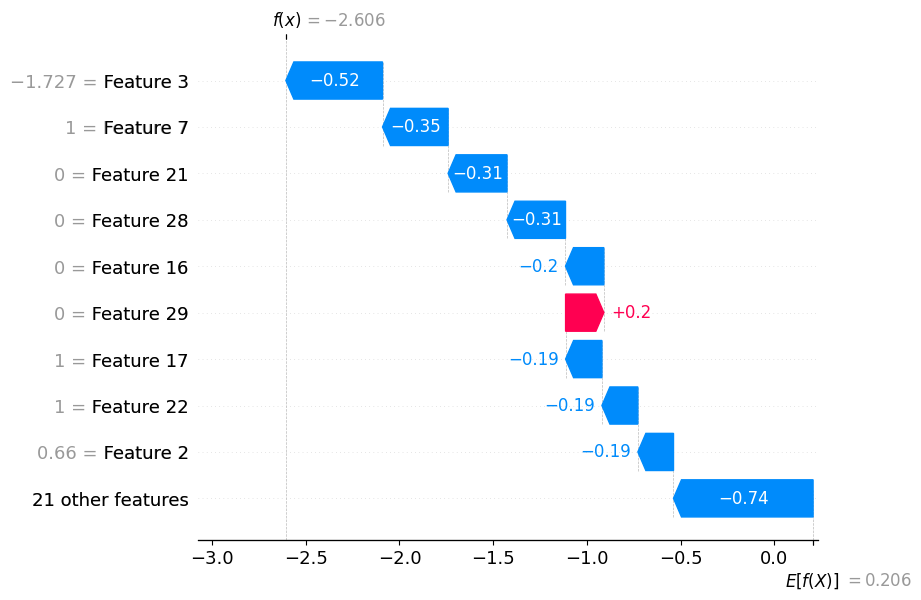

In [75]:
shap.plots.waterfall(patient_shap[0])

In [77]:
print(f"Predicted class: {prediction}")
print(f"Probability of class 1: {probability:.2%}")

Predicted class: 0
Probability of class 1: 6.88%


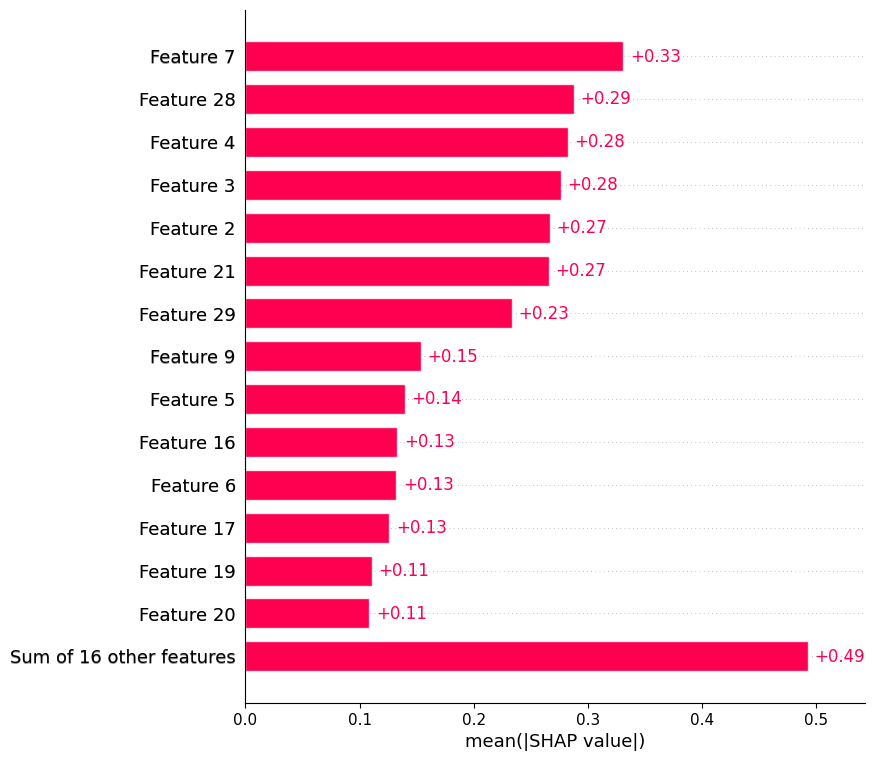

In [79]:
shap.plots.bar(shap_values, max_display=15)

In [80]:
shap_importance = np.abs(shap_values.values).mean(axis=0)

importance_df = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": shap_importance
}).sort_values(
    "mean_abs_shap",
    ascending=False
)

importance_df.head(15)

,feature,mean_abs_shap
7,categorical__cp_0,0.331023
28,categorical__thal_2,0.287671
4,numeric__oldpeak,0.282572
3,numeric__thalach,0.276240
2,numeric__chol,0.266374
21,categorical__ca_0,0.265881
29,categorical__thal_3,0.233244
9,categorical__cp_2,0.153657
5,categorical__sex_0,0.139346
16,categorical__exang_0,0.133136


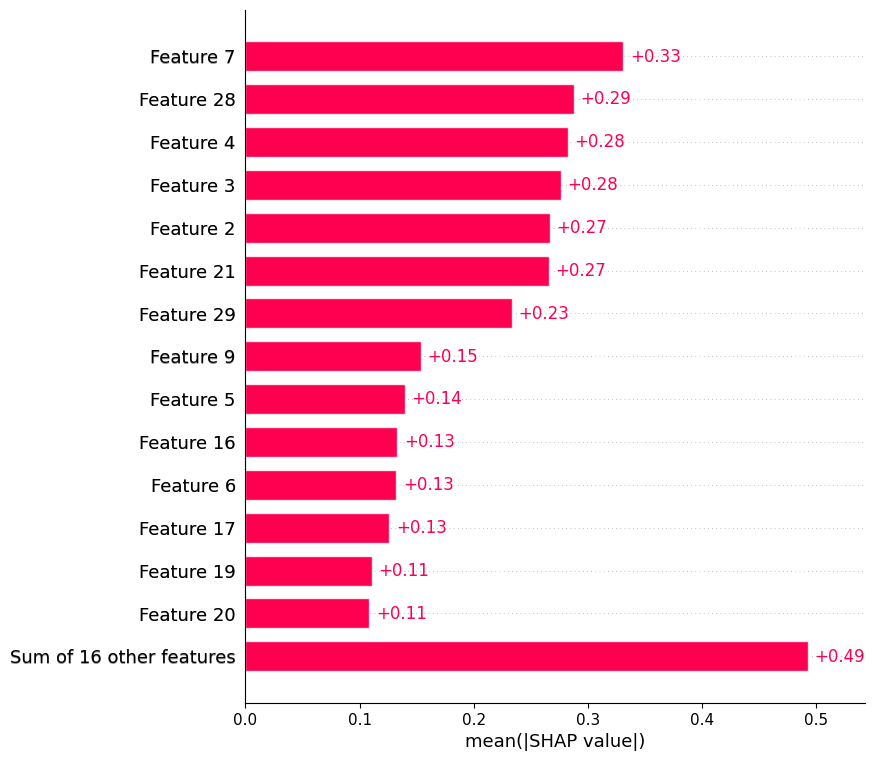

In [81]:
shap.plots.bar(shap_values, max_display=15)

In [82]:
import joblib

joblib.dump(
    best_model,
    "logistic_rhd_demo.pkl"
)

['logistic_rhd_demo.pkl']

In [83]:
import os

print(os.path.getsize("logistic_rhd_demo.pkl"))

5014


In [84]:
loaded_model = joblib.load(
    "logistic_rhd_demo.pkl"
)
test_prediction = loaded_model.predict(X_test.iloc[[0]])[0]

print("Prediction:", test_prediction)


Prediction: 0


Finalizing the model

In [85]:
final_model = grid_search.best_estimator_

final_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'trestbps', 'chol',
                                                   'thalach', 'oldpeak']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'cp', 'fbs',
                                                   'restecg', 'exang', 'slope',
                                                   'ca', 'thal'])])),
                ('classifier',
                 LogisticRegression(C=0.1, max_iter=1000, random_state=42,
                                    solver='liblinear'))])

In [86]:
y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:, 1]

print("FINAL MODEL")
print("----------------")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

FINAL MODEL
----------------
Accuracy : 0.8524590163934426
Precision: 0.8333333333333334
Recall   : 0.9090909090909091
F1 Score : 0.8695652173913043
ROC-AUC  : 0.8939393939393939


In [87]:
import joblib

joblib.dump(final_model, "heart_disease_logistic_model.pkl")

print("Model saved successfully.")

Model saved successfully.


In [88]:
loaded_model = joblib.load("heart_disease_logistic_model.pkl")

prediction = loaded_model.predict(X_test.iloc[[0]])[0]
probability = loaded_model.predict_proba(X_test.iloc[[0]])[0, 1]

print("Prediction:", prediction)
print(f"Probability: {probability:.2%}")

Prediction: 0
Probability: 6.88%
